# Consensus trees

A consensus tree represents an amalgamation of information from multiple trees, usually sharing the same sets of tips. For example, a majority-rule consensus tree represents a tree composed of the most frequently observed clades among a set of trees. Consensus trees often include minimum cut-off values such that nodes are collapsed if a clade is not observed at least some minimum proportion of the time. Consensus trees can also be used to represent more complex results, such as the mean edge length, node height, or trait value observed for each clade in a tree. For exapmle, these values are commonly reported in Bayesian tree inference as the marginal posterior values. 

In [1]:
import toytree
toytree.set_log_level("DEBUG")
from toytree.infer.src.consensus import ConsensusTree

🐞 toytree | logger_setup:set_log_level | toytree v.3.0.5 logging enabled


### 1. perform consensus w/ different tips

In [2]:
# import networkx as nx
import toytree
import toyplot
import numpy as np
import itertools
from collections import defaultdict
from toytree.infer.src.maxcut import *

In [3]:
trees = [
    "((c,d),(a,b));",
    "((b,a),(c,d));",
    #"((b,a),(d,c,f));",
    "((b,a),((d,c),f));",
]
trees = toytree.mtree(trees)

In [4]:
wqrts = get_weighted_quartets_from_trees(trees)
wqrts

{(frozenset({'a', 'b'}), frozenset({'c', 'd'})): 3,
 (frozenset({'a', 'b'}), frozenset({'c', 'f'})): 1,
 (frozenset({'a', 'b'}), frozenset({'d', 'f'})): 1,
 (frozenset({'a', 'f'}), frozenset({'c', 'd'})): 1,
 (frozenset({'b', 'f'}), frozenset({'c', 'd'})): 1}

In [5]:
graph = get_graph_from_quartets_qmc(wqrts)
graph

{frozenset({'b', 'd'}): [3, 0],
 frozenset({'b', 'c'}): [3, 0],
 frozenset({'a', 'd'}): [3, 0],
 frozenset({'a', 'c'}): [3, 0],
 frozenset({'b', 'f'}): [2, 1],
 frozenset({'a', 'f'}): [2, 1],
 frozenset({'d', 'f'}): [2, 1],
 frozenset({'c', 'f'}): [2, 1],
 frozenset({'a', 'b'}): [0, 3],
 frozenset({'c', 'd'}): [0, 3]}

In [89]:
np.random.seed(1234)
graph = get_graph_from_quartets_qmc(wqrts)
nodes = sorted(frozenset.union(*graph))
points = assign_random_points_on_sphere(len(nodes))
sphere = assign_random_points_on_sphere(1000)
dists = get_euclidean_dist_arr(points)
c, a, m = plot_sphere(sphere, points, graph);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="350.0px" height="350.0px" viewBox="0 0 350.0 350.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t2beeafc470484053833981ae864820df"> <g style="fill:rgb(40%,76.1%,64.7%);fill-opacity:1.0;opacity:0.1;stroke:rgb(40%,76.1%,64.7%);stroke-opacity:1.0" class="toyplot-Datum" transform="translate(

23.629974723386322 [ 5.93187575  5.93982572  5.93187575  5.93982572  0.          0.
  0.          0.          0.         -0.11342822]


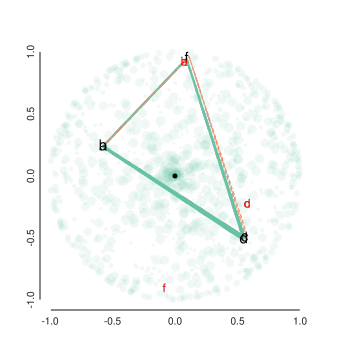

In [107]:
points[0] = points[1]
c, a, m = plot_sphere(sphere, points, graph);
coms, comdists = get_centers_of_mass(points, edges, adists)
#coms, comdists = get_centers_of_mass(points, np.array([[0, 1], [0, 2]]), np.array([1, 1]))
a.text(coms[:, 0], coms[:, 1], nodes, color="red")
#a.text(pp[:, 0], pp[:, 1], nodes, color="blue")
edges, adists = get_edges_and_alpha_distances(nodes, graph, points, 2.0)
print(adists.sum(), adists)
c

In [57]:
import numpy as np

def move_point_by_distance_on_sphere(point, distance):
    """
    Move a point by a given distance on a unit sphere in a random direction.
    
    Parameters:
    point (numpy array): 3D coordinates of the point on a unit sphere (shape: (3,))
    distance (float): The distance by which to move the point on the surface of the unit sphere
    
    Returns:
    numpy array: New 3D coordinates of the point after moving the given distance in a random direction on the unit sphere
    """
    # Generate a random direction on the sphere by creating a random unit vector
    random_direction = np.random.randn(3)
    random_direction /= np.linalg.norm(random_direction)
    
    # Use spherical linear interpolation (slerp) to move the point
    new_point = np.cos(distance) * point + np.sin(distance) * random_direction
    
    # Ensure the result is still on the unit sphere by normalizing it
    new_point /= np.linalg.norm(new_point)
    
    return new_point

# Example usage
point = np.array([1.0, 0.0, 0.0])  # Starting at (1, 0, 0) on the unit sphere
distance = np.pi / 4.  # Move by 45 degrees
new_point = move_point_by_distance_on_sphere(point, distance)
print(new_point)


[0.22219271 0.15004307 0.96338854]


In [56]:
np.pi / 4

0.7853981633974483

In [79]:
# points[0] = points[1]
# points[2] = points[3]
# #points[4] = np.array([1 / np.sqrt(3)] * 3)
# c, a, m = plot_sphere(sphere, points, graph);
# #coms, comdists = get_centers_of_mass(points, edges, adists)
# #coms, comdists = get_centers_of_mass(points, np.array([[0, 1], [0, 2]]), np.array([1, 1]))
# #a.text(coms[:, 0], coms[:, 1], nodes, color="red")
# #a.text(pp[:, 0], pp[:, 1], nodes, color="blue")
# edges, adists = get_edges_and_alpha_distances(nodes, graph, points, 2.0)
# print(adists.sum())
# # 

In [72]:
graph

{frozenset({'a', 'd'}): [3, 0],
 frozenset({'a', 'c'}): [3, 0],
 frozenset({'b', 'd'}): [3, 0],
 frozenset({'b', 'c'}): [3, 0],
 frozenset({'a', 'f'}): [2, 1],
 frozenset({'b', 'f'}): [2, 1],
 frozenset({'d', 'f'}): [2, 1],
 frozenset({'c', 'f'}): [2, 1],
 frozenset({'a', 'b'}): [0, 3],
 frozenset({'c', 'd'}): [0, 3]}

In [91]:
edges, adists = get_edges_and_alpha_distances(nodes, graph, points, 2.0)
adists

array([  1.76341363,   5.64466973,   1.76341363,   5.64466973,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        , -11.91767923])

In [92]:
coms, comdists = get_centers_of_mass(points, edges, adists)
coms, comdists

(array([[ 0.04950011,  0.8504763 , -0.5236791 ],
        [ 0.04950011,  0.8504763 , -0.5236791 ],
        [ 0.92567034, -0.32861161, -0.18748022],
        [ 0.6014866 , -0.18932981, -0.77612376],
        [-0.53605338,  0.14934371, -0.83086896]]),
 array([0.91323783, 0.91323783, 1.22313679, 1.03569545, 0.94115331]))

In [105]:
alpha = 1.74
edges, adists = get_edges_and_alpha_distances(nodes, graph, points, alpha)
score = adists.sum()

for i in range(100):
    
    # get coms of current points
    coms, comdists = get_centers_of_mass(points, edges, adists)
    
    # propose a new point coordinate
    for i in range(points.shape[0]):
        p, com = sample_point_far_from_com(points, coms, comdists)
        #new_coord = get_coordinate_shifted_towards_com(points[p], com, 0.2)
        new_coord = move_point_by_distance_on_sphere(point, distance)
        proposal = points.copy()
        proposal[p] = new_coord
        
        # update dists given the current points
        _, adists = get_edges_and_alpha_distances(nodes, graph, proposal, alpha)
        if adists.sum() > score:
            score = adists.sum()
            points = proposal
            print('accepted', score)
            break
        else:
            pass
            #print('rejected move of', nodes[p])

    #plot_sphere(sphere, points, graph);

In [37]:
sample_point_far_from_com(points, edges, adists)

(2, array([0.59305105, 0.11118164, 0.79745163]))

In [64]:
coms = []
for idx in range(points.shape[0]):
    
    # get which neighbors are connected to this one, e.g. [1, 2, 4, 5]
    point = points[idx]
    idxs = np.nonzero((edges[:, 0] == idx) | (edges[:, 1] == idx))[0]
    neis = sorted(set(edges[idxs].flatten()) - {idx})

    # get their coordinates [[1, 0, 1], [0, 0, 1], ...]
    coos = points[neis]    

    # get their weights [2.1, 1.1, 0.0, -2.1, ...]
    wx = adists[idxs]
   
    # how to handle negative weights?
    #wx[wx < 0] = 0.
    print(wx)
    #print("##", wx - wx.min())
    if not wx.sum():
        wx[:] = 1.
    # elif all(wx < 0):
    #     print(abs(wx - wx.max()), "####")
    #     wx = (1 + (wx - wx.max())) / wx.min()
    else:
        wx = wx / wx.max()
        #wx = (wx - wx.min()) / wx.max()
    print(wx)
    # print(nodes[idx], [nodes[i] for i in neis], wx)
    
    # # get this vertex COM (how to treat negative weights?)        
    com = compute_center_of_mass(points[idx], coos, wx)
    coms.append(com)
    edist = np.linalg.norm(com - point)
    #print(idx, com, edist)

[  5.49735631   3.08068175  -5.48422979 -19.33595614]
[ 1.          0.56039332 -0.99761221 -3.51731906]
[  5.47167893   4.77938194  -7.7121445  -19.33595614]
[ 1.          0.87347631 -1.40946583 -3.53382506]
[  5.49735631   5.47167893  -4.03266124 -31.56973742]
[ 1.          0.99532914 -0.73356374 -5.74271261]
[  3.08068175   4.77938194  -4.44300517 -31.56973742]
[ 0.64457743  1.         -0.92961919 -6.60540166]
[-5.48422979 -7.7121445  -4.03266124 -4.44300517]
[1.35995301 1.91242062 1.         1.10175512]


In [84]:
coms = np.array(coms)

In [98]:
pp = points.copy()
pp[2] = get_coordinate_shifted_towards_com(points[2], coms[2], 0.25)

In [99]:
c, a, m = plot_sphere(sphere, points, graph)
a.text(coms[:, 0], coms[:, 1], nodes, color="red")
a.text(pp[:, 0], pp[:, 1], nodes, color="blue")

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="350.0px" height="350.0px" viewBox="0 0 350.0 350.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="teb4a8d763afa4b97b7f0361c9d91e59f"> <g style="fill:rgb(40%,76.1%,64.7%);fill-opacity:1.0;opacity:0.1;stroke:rgb(40%,76.1%,64.7%);

In [461]:
import numpy as np

def compute_center_of_mass(focal_point, other_points, weights):
    """
    Compute the center of mass (COM) for a focal point based on neighboring points and edge weights.
    
    Parameters:
    focal_point (numpy array): A 3D coordinate of the focal point on a unit sphere (shape: (3,))
    other_points (numpy array): 3D coordinates of other points on a unit sphere (shape: (n, 3))
    weights (numpy array): Weights for edges connecting the focal point to each other point (shape: (n,))
    
    Returns:
    numpy array: 3D coordinate of the center of mass
    """
    # Calculate the weighted sum of the neighboring points
    weighted_sum = np.sum(weights[:, np.newaxis] * other_points, axis=0)
    
    # Normalize the weighted sum by the total weight (absolute sum of weights to handle negative weights)
    total_weight = np.sum(np.abs(weights))
    
    if total_weight == 0:
        return focal_point  # If total weight is zero, return the focal point as the COM
    
    com_vector = weighted_sum / total_weight
    
    # The center of mass may not be on the unit sphere, so normalize it
    com_unit_vector = com_vector / np.linalg.norm(com_vector)
    
    return com_unit_vector



# Example usage
focal_point = np.array([0.0, 0.0, 0.0])
other_points = np.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [1.0, 0., 0.]])
weights = np.array([1.0, -2.0, -1.0])  # Positive and negative weights

com = compute_center_of_mass(focal_point, other_points, weights)
com


array([-0.40824829,  0.40824829, -0.81649658])

In [64]:

def get_vertex_center_of_mass(points, edges, adists):

    coms = {}
    for idx in range(points.shape[0]):
        
        # get which neighbors are connected to this one, e.g. [1, 2, 4, 5]
        point = points[idx]
        idxs = np.nonzero((edges[:, 0] == idx) | (edges[:, 1] == idx))[0]
        neis = sorted(set(edges[idxs].flatten()) - {idx})
    
        # get their coordinates [[1, 0, 1], [0, 0, 1], ...]
        coos = points[neis]    
    
        # get their weights [2.1, 1.1, 0.0, -2.1, ...]
        wx = adists[idxs]

        # get their coms
        com[idx] = get_vertex_center_of_mass(points[idx], coos, wx)

    # return a sample and its com sampled by distance from
    dist_from_com = {}
    
    

In [33]:
pnew = get_cut_from_heuristic_sdp_embedding(graph, alpha=2, seed=1, iters=5000)

ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 2.40293
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 2.75481
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 3.01560
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 3.04461
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 3.27972
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 3.51170
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 3.70985
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 3.89431
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 4.07771
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 4.11233
ℹ️ toytree | maxcut:get_cut_from_heuristic_sdp_embedding | accepted shift, score = 4.27290

In [35]:
plot_sphere(sphere, pnew, graph);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="350.0px" height="350.0px" viewBox="0 0 350.0 350.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t9d364b930df54a5a99ef223b980c748d"> <g style="fill:rgb(40%,76.1%,64.7%);fill-opacity:1.0;opacity:0.1;stroke:rgb(40%,76.1

In [201]:
def get_index_of_furthest_point_from_com(com, points) -> int:
    """Return the index of the point in arr furthest from the COM.

    Parameters
    -----------
    com: Sequence[float]
        A 3D coordinate in (x, y, z).
    arr: ndarray
        A 2D array of shape (N, 3) representing N 3D coordinates.
    """
    # Convert focal_point to a numpy array
    com = np.array(com)

    # Calculate the Euclidean distances from the focal_point to each point in arr
    distances = np.linalg.norm(points - com, axis=1)

    # Find the index of the maximum distance
    furthest_index = np.argmax(distances)
    return furthest_index


def get_coordinate_shifted_towards_com(
    point1: tuple[float,float,float],
    point2: tuple[float,float,float],
    step: float,
) -> tuple[float, float, float]:
    """Return coordinate of point2 shifted closer to point1 on the unit sphere by a specified step.

    Parameters
    ----------
    point1: ndarray
        A 3D coordinate on the unit sphere.
    point2: ndarray
        A 3D coordinate on the unit sphere to be shifted.
    step: float
        A value between 0 and 1 indicating how far to shift point2 towards point1.
    """
    # Ensure the points are numpy arrays
    point1 = np.array(point1)
    point2 = np.array(point2)

    # Calculate the vector from point2 to point1
    direction = point1 - point2
    
    # Calculate the shift amount
    shift_amount = step * np.linalg.norm(direction)

    # Move point2 towards point1
    new_position = point2 + direction / np.linalg.norm(direction) * shift_amount

    # Normalize the new position to ensure it's on the unit sphere
    new_position = new_position / np.linalg.norm(new_position)
    return new_position



In [189]:
toytree.set_log_level("DEBUG")

🐞 toytree | logger_setup:set_log_level | toytree v.3.0.5 logging enabled


In [244]:
tree.draw('n', node_sizes=8, node_mask=False);

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t452cdfca91fc45d68f881559312f4735"> a c b d f

In [41]:
for tree in trees:
    for qrt in tree.enum.iter_quartets():
        print(qrt)

({'b', 'a'}, {'c', 'd'})
({'c', 'd'}, {'b', 'a'})
({'b', 'a'}, {'c', 'd'})
({'b', 'a'}, {'c', 'f'})
({'b', 'a'}, {'d', 'f'})
({'b', 'a'}, {'c', 'd'})
({'c', 'd'}, {'a', 'f'})
({'c', 'd'}, {'b', 'f'})
({'a', 'd'}, {'b', 'c'})
({'c', 'a'}, {'d', 'f'})
({'c', 'a'}, {'b', 'f'})
({'c', 'a'}, {'b', 'd'})
({'b', 'd'}, {'a', 'f'})
({'b', 'd'}, {'c', 'f'})


In [40]:
trees = [
    "((a,b),(c,d));",
    "((c,d),(a,b));",
    "((b,a),(c,d));",
    "((b,a),((d,c),f));",
    "((a,d),(c,b));",
    "((a,c),((b,d),f));",
]
trees = toytree.mtree(trees)

# ConsensusTree(trees).run()

In [42]:
5 / 7

0.7142857142857143

In [151]:
trees = [
    "((a,b),(c,d));",
    "((c,d),(a,b));",
    "((b,a),(c,d));",
    "((b,a),(d,c));",
    "((a,d),(c,b));",
    "((a,c),(b,d));",
]
trees = toytree.mtree(trees)
trees.draw((1, 6), fixed_order=True, ts='c', scale_bar=True, shared_axes=True);
ctree = trees.get_consensus_tree()
c, a, m = ctree.draw();
toytree.annotate.add_edge_labels(ctree, a, labels="support");

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="750.0px" height="250.0px" viewBox="0 0 750.0 250.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t0c7db64a6efe4270b4c9fc28d9c2f057"> a b c d 0 0.5 1 1.5 2 c d a b 0 0.5 1 1.5 2 b a c d 0 0.5 1 1.5 2 b a d c 0 0.5 1 1.5 2 a d c b 0 0.5 1 1.5 2 a c b d 0 0.5 1 1.5 2

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="300.0px" height="275.0px" viewBox="0 0 300.0 275.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tff4bd44ceca544a2a5a410140f9a2914"> a b c d 0.5

In [116]:
def get_clade_frequencies_variable_names(trees: toytree.MultiTree) -> dict[tuple, float]:
    """Return a dict mapping bipartitions to their frequencies.

    This performs one pass through each tree to get its bipartitions. Note
    that feature data (e.g., dists) are not stored here, and require another
    pass later to add to the consensus tree that can be inferred from these
    bipartition frequencies.

    Parameters
    ----------
    trees: MultiTree
        A MultiTree containing multiple ToyTree objects.
    """
    clades = {}
    ntrees = len(trees)

    # iterate over unique topologies
    for utree in trees:
        iter_biparts = toytree.enum.iter_bipartitions(utree, "name", True, False, frozenset, 0)
        for node, bipart in zip(utree, iter_biparts):
            if bipart in clades:
                clades[bipart] += 1
            else:
                clades[bipart] = 1
                
        # add full clade 
        bipart = tuple(sorted(utree.get_tip_labels()))
        if bipart in clades:
            clades[bipart] += 1
        else:
            clades[bipart] = 1
    
    # sort clades by occurrence
    sclades = sorted(clades, key=lambda x: clades[x], reverse=True)

    # sort and convert counts to freqs
    clades = {i: clades[i] for i in sclades}
    for clade in clades:
        clades[clade] = clades[clade] / ntrees
    return clades

get_clade_frequencies(trees)

{(frozenset({'a'}), frozenset({'b', 'c', 'd'})): 0.6666666666666666,
 (frozenset({'b'}), frozenset({'a', 'c', 'd'})): 0.6666666666666666,
 (frozenset({'c'}), frozenset({'a', 'b', 'd'})): 0.6666666666666666,
 (frozenset({'d'}), frozenset({'a', 'b', 'c'})): 0.6666666666666666,
 ('a', 'b', 'c', 'd'): 0.6666666666666666,
 (frozenset({'a', 'b'}), frozenset({'c', 'd'})): 0.3333333333333333,
 (frozenset({'b'}), frozenset({'a', 'c', 'd', 'f'})): 0.3333333333333333,
 (frozenset({'a'}), frozenset({'b', 'c', 'd', 'f'})): 0.3333333333333333,
 (frozenset({'d'}), frozenset({'a', 'b', 'c', 'f'})): 0.3333333333333333,
 (frozenset({'c'}), frozenset({'a', 'b', 'd', 'f'})): 0.3333333333333333,
 (frozenset({'f'}), frozenset({'a', 'b', 'c', 'd'})): 0.3333333333333333,
 ('a', 'b', 'c', 'd', 'f'): 0.3333333333333333,
 (frozenset({'c', 'd'}), frozenset({'a', 'b'})): 0.16666666666666666,
 (frozenset({'a', 'b'}), frozenset({'c', 'd', 'f'})): 0.16666666666666666,
 (frozenset({'c', 'd'}), frozenset({'a', 'b', 'f'

In [152]:
(frozenset({'a'}), frozenset({'b', 'c', 'd'}))[0]

frozenset({'a'})

In [153]:
x = {
    (frozenset(["a", "b"]), frozenset("c")): 2,
    (frozenset(["a", "b", "c"]),): 2,
}

In [154]:
[(frozenset.union(*i), j) for i, j in x.items()]

[(frozenset({'a', 'b', 'c'}), 2), (frozenset({'a', 'b', 'c'}), 2)]

In [157]:
a = frozenset("a")
b = frozenset(('a', 'b'))
a, b

(frozenset({'a'}), frozenset({'a', 'b'}))

In [185]:
# toytree.infer.src.neighbor_joining.infer_neighbor_joining_tree(distances)

In [186]:
t = toytree.rtree.unittree(6)
list(t.enum.iter_bipartitions(None))

[({<Node(idx=0, name='r0')>, <Node(idx=1, name='r1')>},
  {<Node(idx=2, name='r2')>,
   <Node(idx=3, name='r3')>,
   <Node(idx=4, name='r4')>,
   <Node(idx=5, name='r5')>}),
 ({<Node(idx=2, name='r2')>, <Node(idx=3, name='r3')>},
  {<Node(idx=0, name='r0')>,
   <Node(idx=1, name='r1')>,
   <Node(idx=4, name='r4')>,
   <Node(idx=5, name='r5')>}),
 ({<Node(idx=2, name='r2')>,
   <Node(idx=3, name='r3')>,
   <Node(idx=4, name='r4')>},
  {<Node(idx=0, name='r0')>,
   <Node(idx=1, name='r1')>,
   <Node(idx=5, name='r5')>})]

In [187]:
import numpy as np

In [189]:
np.random.RandomState

numpy.random.mtrand.RandomState

In [191]:
rng = np.random.default_rng(123)

In [194]:
isinstance(rng, np.random.Generator)

True

In [106]:
def get_clades_filtered(clades: dict[tuple, float], min_freq: float) -> dict[tuple, float]:
    """...

    """
    keep = {}
    for bipart, freq in clades.items():
        if freq < min_freq:
            continue

        # bipart conflicts with others, discard.
        # ab|cde conflicts w/ ac|bde
        # ab|cd does not conflict with ab|cde
        # abc|d does not conflict with ab|d
        conflict = False
        for t in keep:
            if conflict:
                break
            if t.isdisjoint(bipart[0])
            
                print("IN")

        # passed filters
        if not conflict:
            keep[bipart] = freq
    return keep

clades = get_clade_frequencies(trees)
get_clades_filtered(clades, 0.0)

{(('a',), ('b', 'c', 'd')): 0.6666666666666666,
 (('b',), ('a', 'c', 'd')): 0.6666666666666666,
 (('c',), ('a', 'b', 'd')): 0.6666666666666666,
 (('d',), ('a', 'b', 'c')): 0.6666666666666666,
 ('a', 'b', 'c', 'd'): 0.6666666666666666,
 (('a', 'b'), ('c', 'd')): 0.5,
 (('b',), ('a', 'c', 'd', 'f')): 0.3333333333333333,
 (('a',), ('b', 'c', 'd', 'f')): 0.3333333333333333,
 (('d',), ('a', 'b', 'c', 'f')): 0.3333333333333333,
 (('c',), ('a', 'b', 'd', 'f')): 0.3333333333333333,
 (('f',), ('a', 'b', 'c', 'd')): 0.3333333333333333,
 ('a', 'b', 'c', 'd', 'f'): 0.3333333333333333,
 (('a', 'b'), ('c', 'd', 'f')): 0.16666666666666666,
 (('c', 'd'), ('a', 'b', 'f')): 0.16666666666666666,
 (('a', 'd'), ('b', 'c')): 0.16666666666666666,
 (('a', 'c'), ('b', 'd', 'f')): 0.16666666666666666,
 (('b', 'd'), ('a', 'c', 'f')): 0.16666666666666666}

In [112]:
set(['a', 'b']).issubset(set(['a', 'b', 'c']))

True

In [93]:
# def get_clade_frequencies(trees: toytree.MultiTree) -> dict[str, float]:
#     """Return a dict mapping bipartitions to their frequencies.

#     This performs one pass through each tree to get its bipartitions. Note
#     that feature data (e.g., dists) are not stored here, and require another
#     pass later to add to the consensus tree that can be inferred from these
#     bipartition frequencies.

#     Parameters
#     ----------
#     trees: MultiTree
#         A MultiTree containing multiple ToyTree objects.
#     """
#     clades = {}
#     ntrees = len(trees)

#     # iterate over unique topologies
#     for utree in trees:
#         iter_biparts = toytree.enum.iter_bipartitions(utree, "name", True, False, tuple, True)
#         for node, bipart in zip(utree, iter_biparts):

#             # get node distance unless treenode edge, then sum its children edges
#             clades[bipart]
#             if node.up:
#                 if node.up.is_root():
#                     if len(node.up.children) == 2:
#                         dist = sum(i.dist for i in node.up.children)

#             # store dist and height
#             if bipart not in clades:
#                 clades[bipart] = [1, [node.dist], [node.height]]
#             else:
#                 clades[bipart][0] += 1
#                 clades[bipart][1].append(dist)
#                 clades[bipart][2].append(node.height)

#         # add full clade 
#         bipart = tuple(sorted(utree.get_tip_labels()))
#         if bipart not in clades:
#             clades[bipart] = [1, [utree.treenode.dist], [utree.treenode.height]]
#         else:
#             clades[bipart][0] += 1
#             clades[bipart][1].append(dist)
#             clades[bipart][2].append(node.height)
    
#     # sort clades by occurrence
#     sclades = sorted(clades, key=lambda x: clades[x][0], reverse=True)

#     # sort and convert counts to freqs
#     clades = {i: clades[i] for i in sclades}
#     for clade in clades:
#         clades[clade][0] = clades[clade][0] / ntrees
#     #all_tips = tuple(sorted(set(i[0] for i in sclades if len(i) == 1)))
#     return clades

# get_clade_frequencies(trees, False)

In [50]:
t = trees[0]
list(t.iter_bipartitions("name", True, False, type=tuple, sort=True))

[(('a',), ('b', 'c', 'd')),
 (('b',), ('a', 'c', 'd')),
 (('c',), ('a', 'b', 'd')),
 (('d',), ('a', 'b', 'c')),
 (('a', 'b'), ('c', 'd'))]

In [51]:
t = trees[-1]
list(t.iter_bipartitions("name", True, False, type=tuple, sort=True))

[(('a',), ('b', 'c', 'd')),
 (('c',), ('a', 'b', 'd')),
 (('b',), ('a', 'c', 'd')),
 (('d',), ('a', 'b', 'c')),
 (('a', 'c'), ('b', 'd'))]

In [37]:
c = ConsensusTree(trees)
c._get_all_clade_freqs()

{('a', 'b', 'c', 'd'): (1.0,
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [2.0, 2.0, 2.0, 2.0, 2.0, 2.0]),
 ('a',): [0.9999999999999999,
  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 ('b',): [0.9999999999999999,
  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 ('c',): [0.9999999999999999,
  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 ('d',): [0.9999999999999999,
  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 ('b', 'a'): [0.5, [1.0, 2.0, 2.0], [1.0, 1.0, 1.0]],
 ('c', 'd'): [0.16666666666666666, [1.0], [1.0]],
 ('d', 'a'): [0.16666666666666666, [1.0], [1.0]],
 ('c', 'a'): [0.16666666666666666, [1.0], [1.0]]}

### TESTING

In [5]:
tree = toytree.rtree.unittree(ntips=5, seed=123)

# Get 20 rooted ultrametric trees w/ same topology and variable dists
rutrees = [
   tree.mod.edges_multiplier().mod.edges_slider()
   for i in range(20)]

# Get 20 unrooted ultrametric trees w/ same topology and variable dists
uutrees = [
   tree.unroot().mod.edges_multiplier().mod.edges_slider()
   for i in range(20)]

# Get 20 unrooted non-ultrametric trees w/ same topology and variable dists
untrees = [
   tree.unroot().mod.edges_multiplier().mod.edges_slider()
   for i in range(20)]

## Inferring consensus trees


Let's start by creating three different sets of trees. The first varies in topology, the second varies only in internal node heights but all trees are ultrametric (e.g., a posterior distribution of trees from mrbayes), and the last varies in all edge lengths such that trees are not ultrametric (e.g., a set of maximum likelihood inferred gene trees). 

In [1]:
import toytree

### Example datasets

In [30]:
# a set of simple ultrametric trees
trees = ...

In [24]:
# a set of ultrametric (and presumably) rooted trees
aligned_rooted_trees = toytree.mtree("https://eaton-lab.org/data/densitree.nex")

In [ ]:
# a set of non-ultrametric unrooted trees
unaligned_unrooted_trees = toytree...

In [25]:
fish

<toytree.MultiTree ntrees=160>

In [28]:
# ctree = fish.get_consensus_tree(ultrametric=True)

In [29]:
fish[6].draw();

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="477.048px" height="530.5599999999997px" viewBox="0 0 477.048 530.5599999999997" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t28cab0eed7fc46fcb92ddc3a462ea81f"> Priapella Psjonesii Xclemenciae_G Xsignum Xalvarezi Xmayae Xmonticolus Xhellerii Xandersi Xcouchianus Xgordoni Xmeyeri Xvariatus Xxiphidium Xevelynae Xmilleri Xmaculatus_JpWild Xcortezi Xnezahuacoyotl Xmalinche_CHIC2 Xbirchmanni_GARC Xmontezumae Xcontinens Xpygmaeus Xmultilineatus Xnigrensis

In [17]:
ctree.mod.root_on_minimal_ancestor_deviation(48).draw();

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="477.048px" height="530.5599999999997px" viewBox="0 0 477.048 530.5599999999997" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t8916e12972734114ad1488c592746482"> Xbirchmanni_GARC Xmalinche_CHIC2 Xcortezi Xnezahuacoyotl Xmontezumae Xmultilineatus Xnigrensis Xcontinens Xpygmaeus Xalvarezi Xmayae Xhellerii Xsignum Xclemenciae_G Xmonticolus Xgordoni Xmeyeri Xcouchianus Xvariatus Xevelynae Xmilleri Xxiphidium Xandersi Xmaculatus_JpWild Priapella Psjonesii

### Rooting of consensus trees
A set of input trees may be rooted or unrooted. For example, a set of bootstrap trees from a Maximum Likelihood analysis will typically contain many unrooted trees, whereas a posterior distribution of trees from a Bayesian tree inference analysis will usually contain many rooted trees. The distinction of whether the trees are rooted or not can have implications on the ... By default, `toytree` will attempt to auto-detect whether the trees are rooted or not, but this behavior can be overridden by using the argument ...

### Consensus features

#### dist values
`dist` values (edge lengths) ...

#### height values
...

#### support values
...

#### other features/data
...